#Random Forests


##Recap: Decision Trees
*   Decision Trees split the data based on features to predict outcomes.
*   They’re easy to interpret, fast to train, and handle both classification and regression.
*   However, they have a big weakness: they overfit easily — a single tree can memorize the training data and perform poorly on new data.


##Motivation: From a Single Tree to a Forest


*   Imagine asking one person for their opinion on a tricky question — you might get a biased or extreme answer.
Combine many decision trees to make more robust, generalizable predictions.
*   Now imagine asking a hundred different people and taking the majority vote — your result is likely more balanced and accurate.
*   That’s the key idea behind Random Forests: Combine many decision trees to make more robust, generalizable predictions.





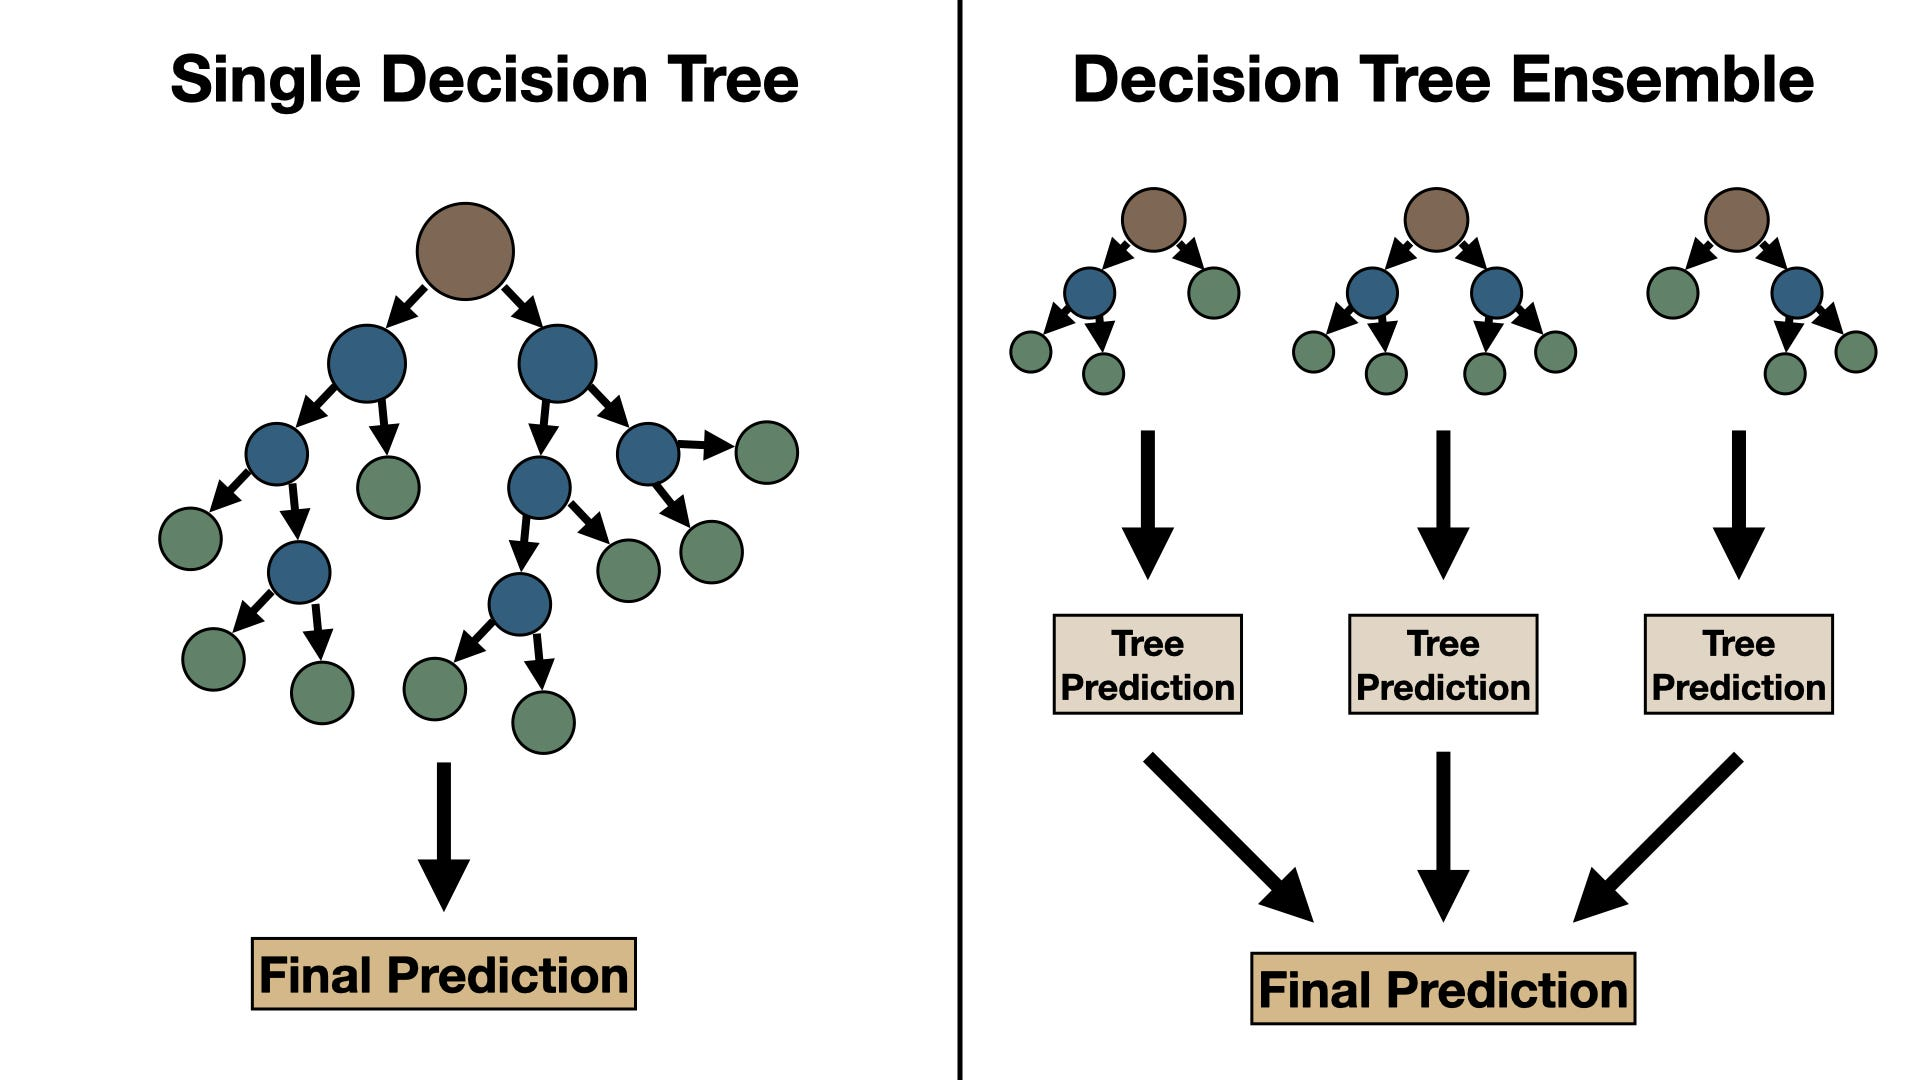



###Let's go back to the Iris flower set from the decision tree:

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


iris = load_iris(as_frame=True)
df = iris.frame
X_train, X_test, y_train, y_test = train_test_split(df[iris.feature_names], iris.target, test_size=0.2)

In [ ]:
##Decision Tree
decisiontree_model = DecisionTreeClassifier()
decisiontree_model.fit(X_train, y_train)

y_pred = decisiontree_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.91      0.83      0.87        12
           2       0.75      0.86      0.80         7

    accuracy                           0.90        30
   macro avg       0.89      0.90      0.89        30
weighted avg       0.91      0.90      0.90        30



In [ ]:
from sklearn.ensemble import RandomForestClassifier

##Random Forest
randomForest_model = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)
randomForest_model.fit(X_train, y_train)

y_pred2 = randomForest_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("\nClassification report:\n", classification_report(y_test, y_pred2))

Accuracy: 0.9

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.85      0.92      0.88        12
           2       0.83      0.71      0.77         7

    accuracy                           0.90        30
   macro avg       0.89      0.88      0.88        30
weighted avg       0.90      0.90      0.90        30



##First Task: Fit a model to the Iris-flower dataset we used with decision trees.
(The decision tree already worked well on the iris set  (Accuracy = 1.0).
Therefore it should also work with an accuracy of 1.0 for RandomForests.)

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load real-world dataset
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Train Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)


print("Random Forest Accuracy :", acc_tree)




Random Forest Accuracy : 0.9415204678362573


In [9]:
##your turn with Random Forest model here
from sklearn.ensemble import RandomForestClassifier

##Random Forest
randomForest_model = RandomForestClassifier(
    n_estimators=900,
    random_state=42
)
randomForest_model.fit(X_train, y_train)

y_pred2 = randomForest_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred2))


Accuracy: 0.9707602339181286


##Visualization of Decision Tree vs Random Forests

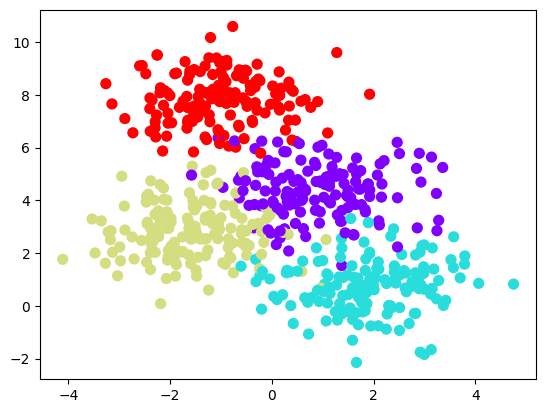

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier

X, y = make_blobs(n_samples=600, centers=4,
                  random_state=0, cluster_std=1.0)

# --- 2. Split into train/test --- (just for accuracy evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

A helper function to make everything more visible:

In [11]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

Tree Accuracy : 1.0


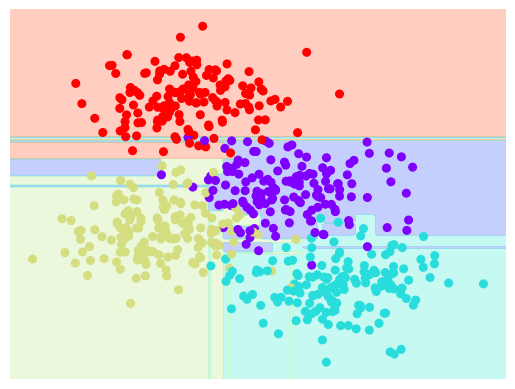

In [16]:
tree = DecisionTreeClassifier().fit(X, y)

tree.fit(X_train, y_train)
visualize_classifier(tree, X, y)

y_pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print("Tree Accuracy :", acc_tree)



forest Accuracy : 1.0


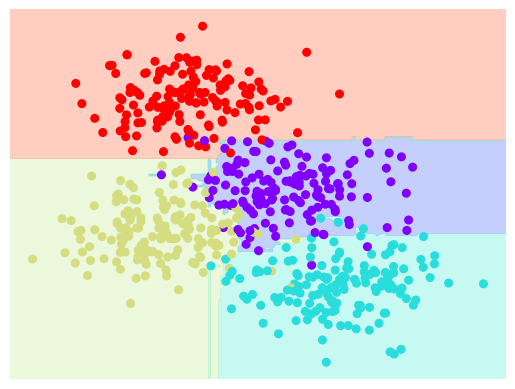

In [17]:
from sklearn.ensemble import RandomForestClassifier

##your turn
forest = RandomForestClassifier().fit(X, y)

forest.fit(X_train, y_train)
visualize_classifier(forest, X, y)

y_pred_forest = forest.predict(X_test)
acc_forest = accuracy_score(y_test, y_pred_forest)
print("forest Accuracy :", acc_forest)




Decision Tree Accuracy : 0.9444444444444444
Random Forest Accuracy : 1.0


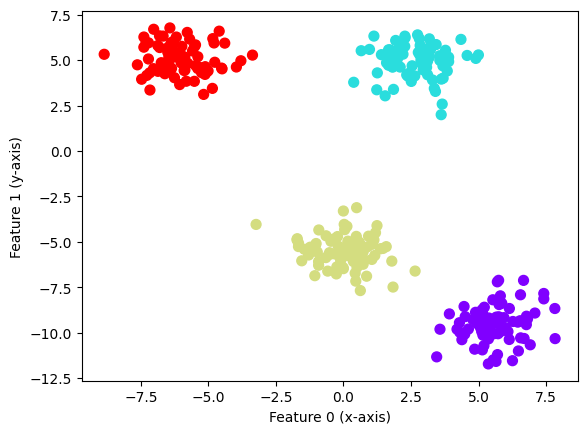

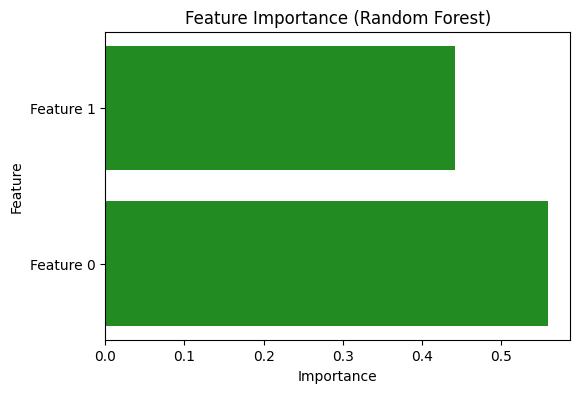

Feature 0: 0.559
Feature 1: 0.441


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# --- 1. Create a synthetic dataset ---
X, y = make_blobs(
    n_samples=300,
    centers=4,
    n_features=2,      # Only 2 features so we can plot them
    random_state=10,
    cluster_std=1.0
)

#X[:, 1] = X[:, 1] * 0    #what happens here

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');
plt.xlabel("Feature 0 (x-axis)")t
plt.ylabel("Feature 1 (y-axis)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- 2. Train models ---
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

# --- 3. Compare accuracies ---
y_pred_tree = tree.predict(X_test)
y_pred_forest = forest.predict(X_test)
print("Decision Tree Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Random Forest Accuracy :", accuracy_score(y_test, y_pred_forest))

# --- 4. Visualize feature importance from Random Forest ---
importances = forest.feature_importances_
features = [f"Feature {i}" for i in range(X.shape[1])]

plt.figure(figsize=(6,4))
plt.barh(features, importances, color='forestgreen')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# --- 5. Optional: print values ---
for name, importance in zip(features, importances):
    print(f"{name}: {importance:.3f}")